## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
import torch
import sys
import os
from torch.utils.data import DataLoader, random_split
import wandb
import random
import datetime

current_dir = os.path.dirname(os.path.abspath(''))
two_up_dir = os.path.dirname(os.path.dirname(current_dir))
sys.path.append(two_up_dir)

from TinyCenterSpeed.src.models.resnet import *
from TinyCenterSpeed.src.models.CenterSpeed import *
from TinyCenterSpeed.dataset.CenterSpeed_dataset import *
from TinyCenterSpeed.src.models.losses import *
from train import *


## Load Data

In [5]:
def cartesian_to_pixel(x, y, image_size=[128,128], pixel_size=0.1):
    pixel_x = int(x / pixel_size + image_size[0] / 2)
    pixel_y = int(y / pixel_size + image_size[1] / 2)
    return pixel_x, pixel_y

transform = transforms.Compose([RandomRotation(45),
                                RandomFlip(0.5)])

set = CenterSpeedDataset('/home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT', transform=None, dense=True)
set.seq_len = 2
set.sx = 1
set.sy = 1

print("set.pixelsize", set.pixelsize)
print("sx,sy", set.sx, set.sy)

print("set.feature_size", set.feature_size)
# set.change_image_size(64)
set.change_image_size(128)
# set.change_pixel_size(0.1)

# independent_test_set = LidarDatasetSeqOD('/home/harry/ros2_ws/src/TinyCenterSpeed/dataset/data/TinyCenterSpeed_dataset/data/validation_set.csv')
# independent_test_set.seq_len = 2

### 추가
training_loader = DataLoader(set, batch_size=32, 
                             shuffle=True, num_workers=4, pin_memory=True, 
                             persistent_workers=True, prefetch_factor=4)
train_size = int(len(set))
print(f"train_size: {train_size}")

Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/1floor_obs1.csv
Entries     :  14576
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/1floor_obs2.csv
Entries     :  11293
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/1floor_obs3.csv
Entries     :  8009
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/1floor_obs4.csv
Entries     :  3813
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/1floor_obs5.csv
Entries     :  4428
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/Spielberg_map_obs1.csv
Entries     :  2361
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/Spielberg_map_obs10.csv
Entries     :  842
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/Spielberg_map_obs2.csv
Entries     :  2143
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/Spielberg_map_obs3.csv
Entries     :  1945
Reading file:  /home/harry/sim_ws/src/f1tenth_gym_ros/Train_GT/Spielberg_map_ob

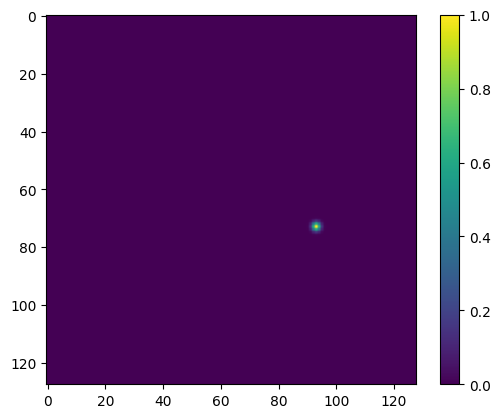

최대값 좌표: (y=73, x=93)
최대값: 1.0
Dense data shape: torch.Size([128, 128, 3]) 

dense_data 의 Vx 픽셀이 가진 값 tensor(-0.5249)
dense_data 의 Vy 픽셀이 가진 값 tensor(0.0013)
dense_data 의 YAW 픽셀이 가진 값 tensor(3.1391) 

gt_heatmap 의 픽셀이 가진 값 tensor(0.0183)


In [14]:
# for idx in range(len(set)):
#     input, gt_heatmap, data, dense_data, is_free = set[idx]

#     print(f'Index: {idx}')
#     print(f'Input shape: {input.shape}')
#     print(f'Data: GT')
#     plt.imshow(gt_heatmap)
#     plt.colorbar()
#     plt.show()
#     plt.close('all')  # 이전 그림 지우기

#     labels = ['VX', 'VY', 'YAW']
#     print(f'Dense data shape: {dense_data.shape}')

#     for i in range(dense_data.shape[2]):
#         plt.imshow(dense_data[:,:,i])
#         print(f'Data: {labels[i]}')
#         print(f'Maximum from data: {data[i+2].item()}')
#         max_value = np.max(dense_data[:,:,i].numpy().flatten())
#         min_value = np.min(dense_data[:,:,i].numpy().flatten())
#         print(f"Maximum value in image slice {i}: {max_value}")
#         print(f"Minimum value in image slice {i}: {min_value}")
#         plt.colorbar()
#         plt.show()
#         plt.close('all')  # 이전 그림 지우기
# # for i in range(0, 1401):


input, gt_heatmap, data, dense_data, is_free = set[252]

# print(f'Input shape: {input.shape}')

# print(f'Data: GT')

plt.imshow(gt_heatmap)
plt.colorbar()
plt.show()



# gt_heatmap은 2D numpy 배열이라고 가정
max_index = np.unravel_index(np.argmax(gt_heatmap), gt_heatmap.shape)
max_value = gt_heatmap[max_index]

print(f"최대값 좌표: (y={max_index[0]}, x={max_index[1]})")
print(f"최대값: {max_value}")

print(f'Dense data shape: {dense_data.shape}','\n')


print("dense_data 의 Vx 픽셀이 가진 값",dense_data[73][93][0])
print("dense_data 의 Vy 픽셀이 가진 값",dense_data[73][93][1])
print("dense_data 의 YAW 픽셀이 가진 값",dense_data[73][93][2],"\n")

labels = ['VX', 'VY', 'YAW']




# for i in range(dense_data.shape[2]):
#     plt.imshow(dense_data[:,:,i])
#     print(f'Data: {labels[i]}')
#     print(f'Maximum from data: {data[i+2].item()}')
#     # Extract and print the maximum value
#     max_value = np.max(dense_data[:,:,i].numpy().flatten())
#     min_value = np.min(dense_data[:,:,i].numpy().flatten())
#     print(f"Maximum value in image slice {i}: {max_value}")
#     print(f"Minimum value in image slice {i}: {min_value}")
#     plt.colorbar()
#     plt.show()

print("gt_heatmap 의 픽셀이 가진 값",gt_heatmap[71][91])


torch.Size([4, 128, 128])
tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..

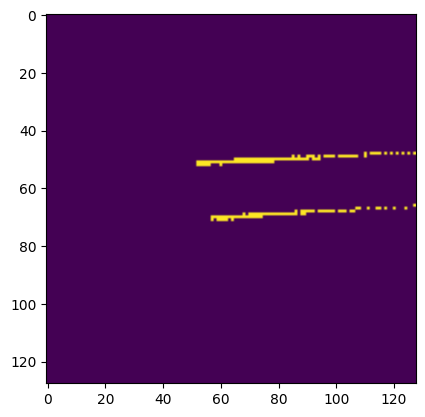

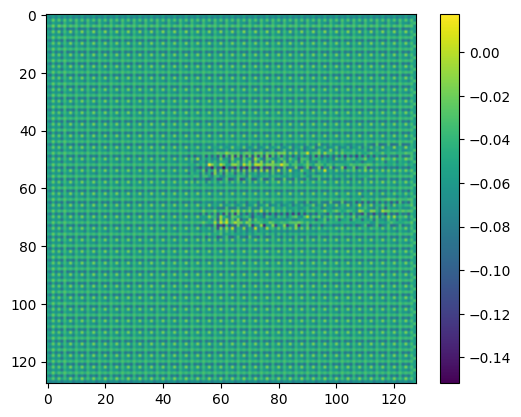

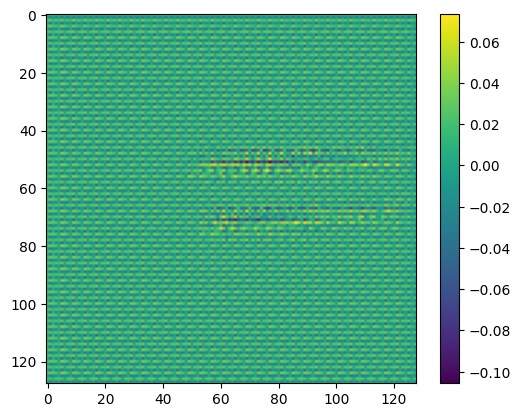

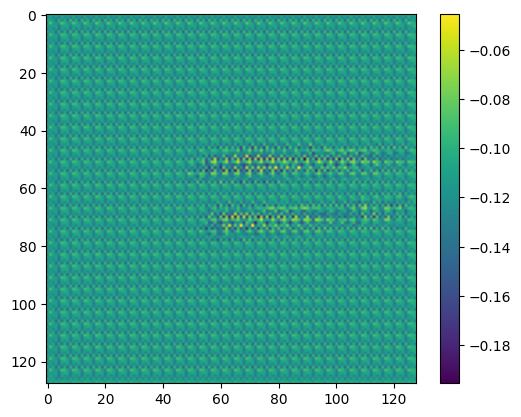

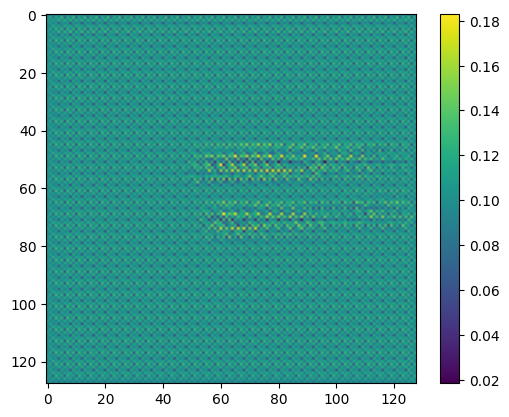

In [35]:
### TEST THE MODEL

model = CenterSpeedDense()
model.eval()

print(input.shape)
print(input.unsqueeze(0))

output = model(input.unsqueeze(0))
print(f'Output shape: {output.shape}')
print(f'Input shape: {input.shape}')

plt.imshow(input[0])
plt.show()

for i in range(output.shape[1]):
    plt.imshow(output[0,i].detach().numpy())
    plt.colorbar()
    plt.show()

Output Shape: torch.Size([1, 4, 128, 128])


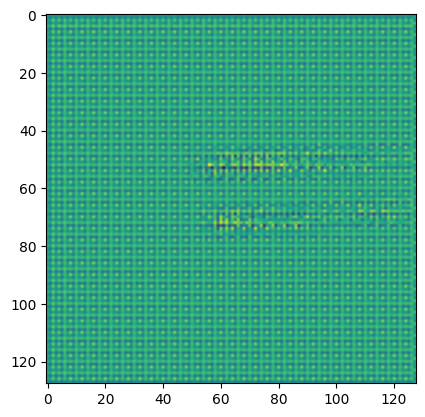

torch.Size([4, 128, 128]) torch.Size([1, 4, 128, 128]) torch.Size([128, 128]) torch.Size([128, 128, 3]) False


In [36]:
### new Loss funcction

def dense_loss(output, gt_heatmap, gt_dense_data, is_free, alpha=0.7, decay=1):

    #### 추가 ####
    device = output.device
    gt_heatmap   = gt_heatmap.to(device, dtype=torch.float32)
    gt_dense_data = gt_dense_data.to(device, dtype=torch.float32)
    ####

    # print(f'Output Shape: {output.shape}')
    # print(f'GT Heatmap Shape: {gt_heatmap.shape}')
    # print(f'GT Dense Shape: {gt_dense_data.shape}')
    
    # fig, ax = plt.subplots(1,3, figsize=(15,5))
    # ax[0].imshow(gt_heatmap[0])
    # ax[0].set_title('GT Heatmap')
    # ax[1].imshow(gt_dense_data[:,:,:,0].squeeze())
    # ax[1].set_title('GT Dense Data')
    # ax[2].imshow(output[0,:,:,0].squeeze().detach().numpy())


    loss = 0
    batch_size = output.shape[0]

    w = gt_heatmap # unit heatmap

    loss += (alpha * (1+w)* (output[:,:,:,0].unsqueeze(-1) - gt_heatmap)**2).sum()
    loss += ((1-alpha) * (1+w)* (output[:,:,:,1:] - gt_dense_data)**2).sum()

    return loss/ batch_size

print(f'Output Shape: {output.shape}')
plt.imshow(output[0,0].detach().numpy())
plt.show()
loss = dense_loss(output.permute(0,2,3,1), gt_heatmap.unsqueeze(0).unsqueeze(-1), dense_data.unsqueeze(0), is_free)
# print(f'Loss: {loss.item()}')
print(input.shape, output.shape, gt_heatmap.shape, dense_data.shape, is_free)

## Parameter Definition

In [ ]:
use_wandb = False
save_code = True
# Define the hyperparameters, logged in wandb
epochs = 100
learning_rate = 5e-4
learning_rate_hm = 0.005
learning_rate_head = 0.005
architecture = "CenterSpeed: Hourglass Deep with Sigmoid, & Dropout, BatchNorm and Head with 2 frames, lower resolution: 64x64, pixelsize 0.1"
dataset = "Transfer learning test"
optimizer = "Adam"
batch_size = 32
timer = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = "CenterSpeed_" + timer
loss_used = "CenterSpeedLossFreev2 with updated logic for free tracks on the dataset level"

#wandb configurations
config = {
    "epochs": epochs,
    "learning_rate": learning_rate,
    "architecture": architecture,
    "dataset": dataset,
    "optimizer": optimizer,
    "Loss-Function": loss_used
}
if use_wandb:
    #initialize wandb run
    run = wandb.init(project="CenterSpeedLowRes", config=config, name=run_name, save_code=save_code)#initialize wandb



train_size = int(len(set) * 0.9)  # 90% for training
val_size = int(len(set) * 0.05)  # 5% for validation since this set is seperate!
test_size = len(set) - (train_size + val_size)  # Remaining 5% for testing

train_dataset, val_dataset, test_dataset = random_split(set, [train_size, val_size, test_size])


training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testing_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle= False)

print("Size of Training Set: ", len(train_dataset))
print("Size of Testing Set: ", len(test_dataset))
print("Size of Validation Set: ", len(val_dataset))

net = CenterSpeedDense(image_size=128)   

optimizer = torch.optim.Adam(net.parameters(), lr= learning_rate)
print("Optimizer Initialized")

loss_fn = dense_loss
print("Loss function initialized")

In [ ]:
def print_learning_rates(optimizer):
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"Learning rate of layer {i}: {param_group['lr']}")

print_learning_rates(optimizer)

net.train()

for name, param in net.named_parameters():
    if param.requires_grad:
        print("GRAD: ", name)
    else:
        print("NO GRAD: ", name)

## Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
from IPython.display import clear_output, display


def train_epoch_Centerspeed_dense(training_loader, net, optimizer, loss_fn, device = 'cpu', use_wandb=False, pdf=None):
    running_loss = 0.
    last_loss = 0.

    plt.ion()
    fig, ax = plt.subplots(1,3, figsize=(15,5))

    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, gts, data, dense_data, is_free = data
        inputs = inputs.to(device)
        gts = gts.to(device)
        data = data.to(device)
        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        output = net(inputs)
        # Compute the loss and its gradients

        loss = loss_fn(output.permute(0,2,3,1), gts.unsqueeze(-1), dense_data, is_free)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()

        last_loss = loss.item() # loss per batch

        ##Plot the input, output and ground truth in a interactive plot
        #### 수정 주석 처리 ####
        # for a in ax:
        #     a.clear()
        # ax[0].imshow(inputs[0,0])
        # ax[0].set_title('Input')
        # ax[1].imshow(output[0,0].detach().numpy())
        # ax[1].set_title('Output')
        # ax[2].imshow(gts[0])
        # ax[2].set_title('Ground Truth')
        # print(np.max(output[0,0].detach().numpy()))
        # clear_output(wait=True)
        # display(fig)


        print('  batch {} loss: {}'.format(i + 1, last_loss))
        
        if use_wandb:
            wandb.log({"batch_loss": last_loss/len(inputs)})#log the average loss per batch

    plt.show()
    return last_loss



In [ ]:



# Initializing in a separate cell so we can easily add more epochs to the same run
#net, optimizer, loss_fn, training_loader, validation_loader = initialize(config)
net.to(device)


# EPOCHS = 10000

EPOCHS = 500
losses = []



for epoch in range(EPOCHS):
    print('Epoch: ', epoch)
    net.train()
    avg_loss = train_epoch_Centerspeed_dense(training_loader=training_loader, net=net, optimizer=optimizer,loss_fn=loss_fn, device=device, use_wandb=False)

    losses.append(avg_loss)

    #save the model
    if epoch % 10 == 0:
    # if epoch % 1 == 0:
        model_path = '/home/harry/ros2_ws/src/TinyCenterSpeed/src/trained_models/redbull_All_obs_0813_epoch_' + str(epoch) + '.pt'
        torch.save(net.state_dict(), model_path)
        #wandb.save(model_path)


plt.plot(losses)
plt.show()

In [ ]:
for name, param in net.named_parameters():
    if param.grad is None:
        print(name, param.data)
    if param.grad is not None:
        print(name)



In [ ]:
input = next(iter(training_loader))[0]

import time
input = input.to(device)
start = time.perf_counter()
output = net(input)
end = time.perf_counter()
print(f'Elapsed time: {(end-start)*1000} ms')
print(f'Input Shape: {input.shape}')
print(f'Output Shape: {output.shape}')

input, gt_heatmap, data, dense_data, is_free = set[100]
output = net(input.unsqueeze(0).to(device))  # ← .to(device) 추가!

In [ ]:
net.load_state_dict(torch.load('/home/harry/ros2_ws/src/TinyCenterSpeed/src/trained_models/train_centerspeed1.pt', weights_only=True))
net.eval()

In [ ]:
input, gt_heatmap, data, dense_data, is_free = set[np.random.randint(0, len(set))]
input = input.unsqueeze(0).to(device)
output = net(input.to(device))
plt.imshow(input[0,0].to(device).detach().cpu().numpy())
plt.show()
max_index = np.unravel_index(output[0,0].to(device).detach().cpu().numpy().argmax(), output[0,0].shape)
print(data)
for i in range(output.shape[1]):
    plt.imshow(output[0,i].detach().cpu().numpy())
    plt.plot(max_index[1], max_index[0], 'ro')
    plt.colorbar()
    plt.show()
    if i == 0:
        print(f'Output: Heatmap')
        continue

    value_at_max = output[0,i].detach().cpu().numpy()[max_index]
    max_value = np.max(output[0,i].detach().cpu().numpy())
    min_value = np.min(output[0,i].detach().cpu().numpy())

    print(f'GT: {data[1+i]} ')
    print(f'Output: {value_at_max} ')
    print(f'Maximum value in image slice {i}: {max_value}')
    print(f'Minimum value in image slice {i}: {min_value}')
